# Motor de diseño de la neurona LIF

De una especificación de comportamiento a un layout verificado.

El motor tiene dos capas y este notebook las recorre por separado para que se vea
dónde acaba una y empieza la otra:

1. **Caracterización** — de lo que pides (frecuencia, corriente de entrada) a las
   dimensiones de los dispositivos. Cinco leyes ajustadas sobre simulación.
2. **Layout** — de esas dimensiones a un GDS: placement por bandas, ruteo, rieles.

Y dos verificaciones, porque una sola no basta: el DRC dice si las formas son legales,
no si están conectadas.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import pathlib
import sys

# el paquete vive en designs/scripts/lif_design; se busca subiendo desde aqui
raiz = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / 'designs' / 'scripts' / 'lif_design').exists())
sys.path.insert(0, str(raiz / 'designs' / 'scripts'))

from glayout import gf180
gf180.activate()

from lif_design.spec import NeuronSpec
from lif_design.solver import design
from lif_design.build import from_design
from lif_design import mim, check

print('deck de DRC:', check.DECK)
print('salida:     ', check.SALIDA)


deck de DRC: /tmp/glayout/src/glayout/pdk/gf180_mapped/gf180mcu.drc
salida:      /tmp/nbout


## Capa 1 — de la intención a las dimensiones

`NeuronSpec` es lo que pides. Todo es opcional: `None` significa *decide tú*, que no es
lo mismo que un valor por defecto — es lo que le da libertad al solver.

`design()` **nunca lanza una excepción**. Siempre devuelve la mejor solución alcanzable
más una lista de notas explicando qué decidió, qué cambió y por qué. Si pides algo
imposible te lo dice con la cadena causal, no con un stack trace.


In [3]:
d = design(NeuronSpec(freq_range=500, iex_range=100))

print('resoluble:', d.ok)
print()
print('dimensiones que salen:')
for k, v in d.params.items():
    print('   %-8s %8.2f' % (k, v))
print()
print('comportamiento predicho:')
for k, v in d.predicted.items():
    print('   %-14s %s' % (k, v))
print()
for n in d.notes:
    print(n)


resoluble: True

dimensiones que salen:
   W_M5         1.67
   L_M5        35.42
   Cm         222.00
   W_M7M8       0.22

comportamiento predicho:
   k [kHz/nA]     4.756
   f a 100 nA [kHz] 499.9
   f en el rango [kHz] (499.9, 499.9)
   Vth [V]        1.701
   swing [V]      1.306
   Cm_min [fF]    185.0
   ventana Iex [nA] (5.0, 900.2)
   C_in [fF]      2.39
   C_load max [fF] 132.0

[INFO] frecuencia: objetivo puntual: 500.0 kHz a 100.0 nA
[INFO] geometria: W=1.671 L=35.4 elegidas por margen de validez (habia una familia de soluciones sobre la curva de iso-frecuencia)
[INFO] Cm: sin objetivo de Vth; se usa 1.2 x Cm_min = 222 fF (margen sobre el limite de operacion)


### Qué pasa cuando pides algo que no se puede

Los objetivos mandan sobre las dimensiones fijadas. Si fijas una dimensión que estorba,
se ajusta y te avisa; sólo cuando la contradicción no tiene salida sale error.


In [4]:
apretado = design(NeuronSpec(Cm=52, iex_range=100))
print('resoluble:', apretado.ok, '  Cm final: %.1f fF' % apretado.params['Cm'])
for n in apretado.notes:
    print(n)


resoluble: True   Cm final: 174.3 fF
[WARNING] Cm: subida de 52 a 174 fF: bajo Cm_min la membrana sale del riel
    cadena: Cm_min(W=1.25, L=50.0) = 174 fF


### Las tres clases de entrada

`NeuronSpec` no tiene modos ni variantes: tiene tres clases de campo, y cualquier
combinación es válida.

| clase | campos | qué hacen |
|---|---|---|
| **objetivos** | `freq_range`, `iex_range`, `vth`, `c_load` | mandan sobre todo lo demás |
| **dimensiones fijadas** | `W_M5`, `L_M5`, `Cm`, `W_M7M8` | se respetan mientras no estorben |
| **contexto** | `source_ro`, `freq_tolerance` | no dirigen la solución, acotan el error |

Los rangos aceptan un par o un número suelto, y esa diferencia **cambia el problema**:
con `iex_range` fijo se persigue un punto de operación, y con un rango se persigue una
*pendiente* — la ganancia `k` en kHz/nA. No es lo mismo pedir 500 kHz que pedir que la
neurona recorra de 200 a 800 kHz mientras la corriente va de 50 a 200 nA.

In [5]:
casos = [
    ('frecuencia exacta',       NeuronSpec(freq_range=500, iex_range=100)),
    ('rango de frecuencia',     NeuronSpec(freq_range=(400, 600), iex_range=100)),
    ('rango en ambos: ganancia',NeuronSpec(freq_range=(200, 800), iex_range=(50, 200))),
    ('L fijada, W libre',       NeuronSpec(freq_range=500, iex_range=100, L_M5=40.0)),
    ('objetivo de Vth',         NeuronSpec(freq_range=500, iex_range=100, vth=1.5)),
    ('con carga de salida',     NeuronSpec(freq_range=500, iex_range=100, c_load=80.0)),
]

print('%-26s %7s %7s %8s   %s' % ('lo que pides', 'W_M5', 'L_M5', 'Cm', 'avisos'))
print('-' * 78)
for nombre, s in casos:
    d = design(s)
    avisos = [n for n in d.notes if n.severity != 'info']
    print('%-26s %7.2f %7.2f %8.1f   %s' % (
        nombre, d.params['W_M5'], d.params['L_M5'], d.params['Cm'],
        '%d' % len(avisos) if avisos else '-'))

lo que pides                  W_M5    L_M5       Cm   avisos
------------------------------------------------------------------------------
frecuencia exacta             1.67   35.42    222.0   -
rango de frecuencia           1.41   35.42    186.2   -
rango en ambos: ganancia      2.06   35.42    275.3   -
L fijada, W libre             1.50   40.00    216.5   -
objetivo de Vth               1.24   50.00    510.7   -
con carga de salida           1.67   35.42    222.0   -


### Cuando lo que pides se contradice

Aquí es donde se ve la prioridad. Se fijan `W` y `L` **y** se pide una frecuencia que
esas dos dimensiones no dan. El motor no elige por su cuenta ni aborta: enseña las dos
salidas que evaluó, dice cuál descartó y por qué, y ajusta lo mínimo.

In [6]:
d = design(NeuronSpec(freq_range=500, iex_range=100, W_M5=3.0, L_M5=25.0))

print('resoluble:', d.ok)
for k, v in d.params.items():
    print('   %-8s %8.2f' % (k, v))
print()
for n in d.notes:
    print(n)

resoluble: True
   W_M5         2.75
   L_M5        20.00
   Cm         249.90
   W_M7M8       0.22

[INFO] frecuencia: objetivo puntual: 500.0 kHz a 100.0 nA
[WARNING] frecuencia: W=3.0 y L=25.0 fijas dan 370 kHz, no 500. Los objetivos tienen prioridad, asi que se ajustan las dimensiones
    cadena: liberar L_M5 -> exigiria L=18.1 um (fuera de 20.0-50.0) | liberar W_M5 -> W=2.265 um
[WARNING] W_M5: cambiada de 3.0 a 2.753 um; L_M5 tambien a 20.0 um
[INFO] Cm: sin objetivo de Vth; se usa 1.2 x Cm_min = 250 fF (margen sobre el limite de operacion)
[WARNING] L_M5: 20.0 um: bajo 25.0 um el error de la ley de frecuencia sube de ~1% a 5-7%


Y un límite que no es de las leyes sino del silicio: sobre `F_MAX = 4500 kHz` el reset no
llega a completarse. Las leyes despejan igual y devuelven una geometría de aspecto
razonable, así que sin el aviso el motor entregaría en silencio una celda que no dispara.

In [7]:
for f in (2000, 4500, 6000):
    d = design(NeuronSpec(freq_range=f, iex_range=100))
    avisos = [n for n in d.notes if n.severity != 'info']
    print('%5d kHz -> %s' % (f, avisos[0].message if avisos else 'dentro de rango'))

 2000 kHz -> dentro de rango
 4500 kHz -> dentro de rango
 6000 kHz -> 6000 kHz esta sobre el maximo medido (4500 kHz): la geometria sale de las leyes, pero el reset no completa y la celda no llegara a esa frecuencia


### El contexto: la fuente de corriente no es ideal

Las cinco leyes se midieron sobre `tb_charac_isrc.spice`, con una **fuente de corriente
ideal en lugar de M6** — el transistor de entrada. Eso no es un descuido: en este diseño
M6 no vive en la neurona, vive en el **encoder**, que entrega cuatro corrientes
(`Iex_1_i` … `Iex_4_i`) desde sendos pfets de espejo.

Una fuente ideal tiene impedancia de salida infinita; un pfet real, no. `source_ro`
existe para cuantificar esa diferencia en vez de ignorarla. El error va como `1/ro`:

In [8]:
print('el error va como 1/ro:')
print()
for ro in (5e6, 2e7, 1e8, 2e8, 5e8, 1e9):
    d = design(NeuronSpec(freq_range=500, iex_range=100, source_ro=ro))
    nota = next((n for n in d.notes if n.subject == 'fuente'), None)
    print('   ', nota.message if nota else 'sin aviso')

print()
print('para bajar del 5% hace falta ro >= ~400 MOhm')


el error va como 1/ro:

    con ro=5 MOhm el error de frecuencia sera ~380.0%
    con ro=20 MOhm el error de frecuencia sera ~95.0%
    con ro=100 MOhm el error de frecuencia sera ~19.0%
    con ro=200 MOhm el error de frecuencia sera ~9.5%
    con ro=500 MOhm el error de frecuencia sera ~3.8%
    con ro=1000 MOhm el error de frecuencia sera ~1.9%

para bajar del 5% hace falta ro >= ~400 MOhm


### Lo que la celda le ofrece a la etapa previa

`source_ro` es lo que le **exigimos** a la fuente. `C_in` es lo que le
**ofrecemos**: la capacidad que ve colgando del nodo, aparte de `Cm`.

Es el dual de `c_load`. Nuestro `c_load` es el `C_in` de la celda siguiente, y
nuestro `C_in` es el `c_load` de la anterior; cuando el generador encadene
codificador -> LIF -> sinapsis, este numero es el que viaja hacia arriba.

Se midio como `C_total - Cm`, con `C_total = Iex/(dV/dt)` sobre la rampa de
integracion: la propia fuente cargando el nodo *es* la medida. Sale afin y solo
en `W_M5` -- el termino constante son las puertas de M1/M2, que cuelgan del
nodo aunque M5 sea minimo, y el lineal es la union de drenador de M5.

**No se suma a `f`.** La ley de frecuencia se ajusto sobre simulaciones del
circuito completo que ya lo contienen; sumarlo otra vez lo contaria dos veces.

In [9]:
print('%-10s %7s %9s %7s %9s' % ('f pedida', 'W_M5', 'Cm', 'C_in', 'C_in/Cm'))
print('-' * 48)
for f in (200, 500, 1000, 2000, 4000):
    d = design(NeuronSpec(freq_range=f, iex_range=100))
    ci, cm = d.predicted['C_in [fF]'], d.params['Cm']
    print('%7d kHz %7.3f %9.1f %7.2f %8.2f%%'
          % (f, d.params['W_M5'], cm, ci, 100 * ci / cm))

f pedida      W_M5        Cm    C_in   C_in/Cm
------------------------------------------------
    200 kHz   3.176     511.4    3.69     0.72%
    500 kHz   1.671     222.0    2.39     1.08%
   1000 kHz   0.877     113.8    1.70     1.49%
   2000 kHz   0.461      60.0    1.34     2.23%
   4000 kHz   0.273      60.0    1.18     1.97%


In [10]:
# c_in_max se comprueba, no se resuelve. C_in solo va de 1.1 a 4.0 fF en todo
# el envolvente, asi que la cota casi nunca puede morder; resolverla gastaria
# W_M5, que es el mando mas caro de la cadena de ajuste.
for tope in (3.0, 1.2):
    d = design(NeuronSpec(freq_range=1500, iex_range=100, c_in_max=tope))
    avisos = [n for n in d.notes if n.subject == 'C_in']
    print('c_in_max = %.1f fF  ->  %s'
          % (tope, avisos[0].message if avisos else 'lo cumple, sin aviso'))

c_in_max = 3.0 fF  ->  lo cumple, sin aviso
c_in_max = 1.2 fF  ->  el diseño presenta C_in=1.47 fF a la etapa previa, sobre el maximo pedido de 1.20 fF; haria falta W_M5 <= 0.295 um


## Capa 2 — de las dimensiones al layout

`from_design()` es la unión entre las dos capas. Devuelve el componente, los handles de
cada bloque (para poder sondearlos después) y sus propias notas: las de esta capa hablan
de lo que se pierde al pasar de un número continuo a geometría.


In [11]:
# El ejemplo canonico, el mismo del README: 500 kHz a 100 nA. Se resuelve
# aqui en vez de heredar `d`, que para este punto ya paso por siete barridos
# y traia el ultimo -- 1500 kHz con tope de c_in -- dibujando una celda que
# no era la que el texto describe.
d_demo = design(NeuronSpec(freq_range=500, iex_range=100))
celda, h, notas = from_design(gf180, d_demo, name='lif_demo')

bb = celda.bbox
ancho, alto = bb[1][0] - bb[0][0], bb[1][1] - bb[0][1]
print('caja: %.2f x %.2f um = %.0f um2' % (ancho, alto, ancho * alto))
print('esquina inferior izquierda: (%.3f, %.3f)' % (bb[0][0], bb[0][1]))
print('bloques:', {k: (len(v) if isinstance(v, list) else 1)
                   for k, v in h.items() if k in ('nfets', 'pfets', 'caps', 'm5')})
print()
for n in notas:
    print(n)

gds = '%s/lif_demo.gds' % check.SALIDA
celda.write_gds(gds)


caja: 40.73 x 25.95 um = 1057 um2
esquina inferior izquierda: (0.000, 0.000)
bloques: {'nfets': 3, 'pfets': 3, 'caps': 3, 'm5': 1}

[INFO] Cm: pedida 222.0 fF -> 3 MIM de 5.870 um de lado = 222.5 fF (+0.2%), con cap_mim_2f0_m4m5_noshield
    cadena: snap a rejilla del lado del MIM


'/tmp/nbout/lif_demo.gds'

### El condensador no es área por densidad

Esta es la conversión menos obvia entre las dos capas. El solver da Cm en fF y el layout
necesita un lado en µm, pero el modelo del PDK no es una densidad plana:

    C = c_cox · area + c_capsw · perimetro

A nuestro tamaño el término de perímetro **no** es despreciable: en un MIM de 5 µm de
lado aporta el 21% del total con la receta de 1.0 fF/µm². Multiplicar área por la
densidad que dice el nombre del modelo se queda corto justo donde trabajamos.

Además `MIM.8a` no deja un FuseTop de menos de 25 µm², o sea 5 µm de lado. Por eso el
número de MIM en paralelo baja solo cuando la membrana es pequeña.

El ejemplo de abajo lo enseña: con 95 fF (lo que pide 1200 kHz), la receta densa se
queda sin margen para repartir y se ve forzada a un solo MIM, mientras la ligera aun
cabe en tres. Es granularidad de la regla, no un fallo.


In [12]:
print('%-6s %16s %14s   %s' % ('receta', 'c_cox', 'c_capsw', 'MIM minimo (5x5)'))
for r, (cox, sw) in mim.DENSIDADES.items():
    print('%-6s %9.3f fF/um2 %8.3f fF/um   %.1f fF'
          % (r, cox, sw, mim.capacidad(5.0, r, 1)))
print()
# 95 fF es la membrana que sale a 1200 kHz, donde el limite muerde
for r in mim.DENSIDADES:
    for n in (1, 2, 3):
        lado = mim.lado_para(95.0, mim=r, n=n)
        print('   Cm=95 fF  %s con %d MIM -> %5.2f um de lado   %s'
              % (r, n, lado, 'ok' if lado >= 5.0 else 'ILEGAL por MIM.8a'))


receta            c_cox        c_capsw   MIM minimo (5x5)
1f0        0.987 fF/um2    0.330 fF/um   31.3 fF
2f0        1.990 fF/um2    0.238 fF/um   54.5 fF

   Cm=95 fF  1f0 con 1 MIM ->  9.16 um de lado   ok
   Cm=95 fF  1f0 con 2 MIM ->  6.30 um de lado   ok
   Cm=95 fF  1f0 con 3 MIM ->  5.03 um de lado   ok
   Cm=95 fF  2f0 con 1 MIM ->  6.67 um de lado   ok
   Cm=95 fF  2f0 con 2 MIM ->  4.65 um de lado   ILEGAL por MIM.8a
   Cm=95 fF  2f0 con 3 MIM ->  3.76 um de lado   ILEGAL por MIM.8a


## Verificación 1 — DRC

Con dos trampas del deck que conviene conocer, porque las dos devuelven verde
sin comprobar lo que crees.

El deck que trae glayout arranca `MIM_OPTION` a `"Nan"`, y todo el bloque de MIM es un
`if A ... elsif B`. Si no le pasas la opción **no comprueba ni una sola regla de MIM**.
Y arranca `METAL_LEVEL` a `"6LM"`, mientras el deck del propio PDK asume `5LM`: con seis
metales el deck cree que la cima es metaltop, así que `topmin1_via` pasa a ser via4 —
justo la via del MIM en opción B — y `MIMTM.10` acusa al condensador de llevar vias
prohibidas que son las suyas.

`check.drc()` deriva las dos del PDK en vez de fijarlas a mano: `_mim_option()` mira
dónde pone el PDK las placas y `_metal_level()` cuenta los metales de la pila. Hoy sale
**opción B** — placa inferior en met4, FuseTop encima, placa superior en met5 y contacto
por via4 — y `5LM`. Si mañana el PDK se configura en opción A, el deck se entera solo.

In [13]:
n, categorias = check.drc(gds, 'lif_demo')
print('violaciones:', n, categorias if categorias else '')


violaciones: 0 


## Verificación 2 — conectividad

El DRC no ve cortos ni nodos flotantes, así que hace falta mirar la conectividad aparte.

`netcheck.py` recorre el metal directamente: funde cada capa y deja que cada via suelde
lo que toca. Modela aparte que la via que aterriza sobre FuseTop contacta la placa
**superior**, no la inferior que hay debajo — sin eso todos los condensadores salen como
un cortocircuito. Qué via sea depende de dónde ponga el PDK el MIM: via2 con las placas
en met2/met3, **via4 con las placas en met4/met5**, que es donde están ahora.

Nació porque el extractor no servía: el techfile de magic para gf180 pone el MIM entre
metal4 y metal5 y el nuestro estaba en met2/met3, así que `ext2spice` no veía los
condensadores. Con la migración a opción B esa discrepancia concreta desaparece, pero
`netcheck` se queda: es rápido, no necesita magic, y responde la pregunta que interesa
aquí — qué está unido con qué. Los dispositivos y sus parámetros los cubre el LVS, más
abajo.

Se sondean puntos concretos y se agrupan por red. Las seis que tiene que haber:

In [14]:
import json

puntos = check.sondas(h, bb)
ruta = '%s/lif_demo.json' % check.SALIDA
json.dump(puntos, open(ruta, 'w'))

grupos = check.redes(gds, ruta)
quiero = check.esperado(len(h['caps']))

for red, miembros in quiero.items():
    if any(g == miembros for g in grupos):
        print('  OK     %-11s %s' % (red, ' '.join(sorted(miembros))))
    else:
        visto = next((g for g in grupos if g & miembros), set())
        print('  FALLA  %-11s esperaba %s' % (red, ' '.join(sorted(miembros))))
        print('         %-11s salio    %s' % ('', ' '.join(sorted(visto)) or 'partida'))


  OK     membrana    M5_drain cap0_arriba cap1_arriba cap2_arriba nfet0_gate pfet0_gate
  OK     spike_neg   nfet0_drain nfet1_gate nfet2_gate pfet0_drain pfet1_gate pfet2_gate
  OK     realimenta  M5_gate nfet1_drain pfet1_drain
  OK     salida      nfet2_drain pfet2_drain
  OK     VDD         pfet0_source pfet1_source pfet2_source riel_VDD
  OK     VSS         M5_source cap0_abajo cap1_abajo cap2_abajo nfet0_source nfet1_source nfet2_source riel_VSS


## El dibujo

Recordatorio de por qué esto está aquí y no es decoración: varias veces la celda tenía
DRC 0 y estaba mal, y fue mirando el PNG como se vio.


escrito /tmp/nbout/lif_demo.png


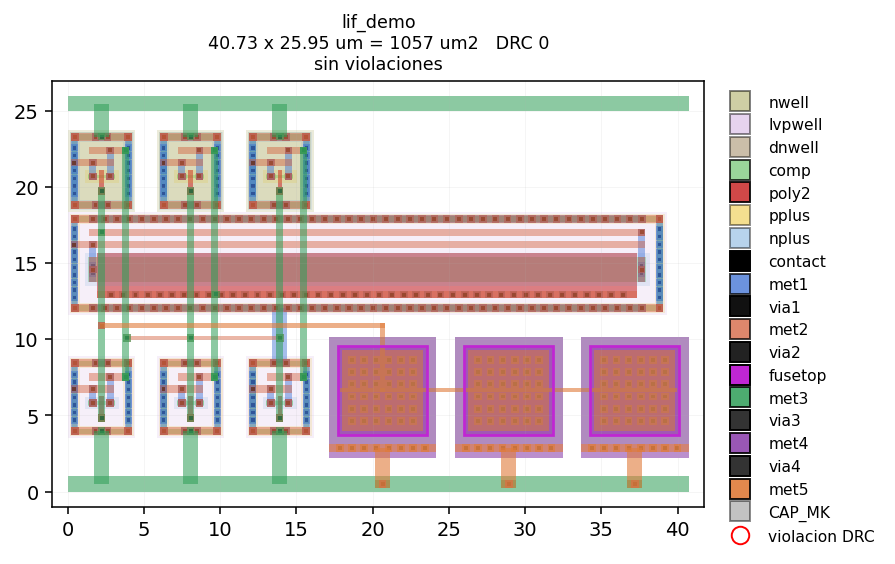

In [15]:
import subprocess
from IPython.display import Image, display

png = '%s/lif_demo.png' % check.SALIDA
lyrdb = '%s/lif_demo.lyrdb' % check.SALIDA
subprocess.run([sys.executable,
                str(raiz / 'designs' / 'scripts' / 'lif_design' / 'preview.py'),
                png, '%s:%s' % (gds, lyrdb)], check=True)
display(Image(filename=png))


## Verificación 3 — LVS

`netcheck` dice qué está unido con qué, pero no mira etiquetas ni dispositivos. El LVS
mira las tres cosas, y las tres se le escapan a las otras dos comprobaciones: una
etiqueta puesta sobre la red equivocada pasa el DRC y pasa `netcheck` sin quejarse.

Aquí el LVS no es un *descubrimiento* sino una *comprobación*. En un flujo a mano se
dibuja el esquemático por un lado y el layout por otro, y la comparación revela si
divergieron. Estos dos salen de la misma `NeuronDesign`, así que un fallo solo puede
significar un bug del generador: la clase de fallo "alguien tecleó distinto en dos
sitios" no existe.

Dos detalles que costaron encontrarlos, los dos por la misma razón — lo declarado no era
lo dibujado:

- El deck extrae el condensador como **`cap_mim_2f0fF`**, sin sufijo de metales, mientras
  el modelo de *simulación* es `cap_mim_2f0_m4m5_noshield`. Dos nombres para lo mismo, y
  el netlist tiene que usar el primero. De ahí `mim.modelo()` y `mim.modelo_lvs()`.
- El GDS se escribe en rejilla de 0.005 µm y tanto la placa del MIM como el canal de un
  FET van centrados, así que los bordes se van hacia fuera: una placa de 5.864 sale
  dibujada de 5.87 y un M5 de 1.671 sale de 1.68. `en_rejilla()` sube cada dimensión a
  esa rejilla antes de construir, y `handles["dims"]` lleva lo dibujado — que es de donde
  lee el netlist, no de `design.params`.

In [16]:
# El netlist de referencia sale del mismo diseno que el layout.
from lif_design import netlist

d_lvs = design(NeuronSpec(freq_range=500, iex_range=100))
celda_lvs, h_lvs, _ = from_design(gf180, d_lvs, name='lif_lvs')

print(netlist.de_diseño(d_lvs, h_lvs, name='lif_lvs'))
print('lado dibujado del MIM:', h_lvs['cap_lado'], 'um')
print('dimensiones dibujadas:', h_lvs['dims'])

.subckt lif_lvs Vdd Vss Iin spike spike_neg
*.PININFO Vdd:B Vss:B Iin:I spike:O spike_neg:O
M1 spike_neg Iin Vdd Vdd pfet_03v3 L=0.28u W=0.22u nf=1 m=1
M2 spike_neg Iin Vss Vss nfet_03v3 L=0.28u W=0.22u nf=1 m=1
M3 spike/reset spike_neg Vdd Vdd pfet_03v3 L=0.28u W=0.22u nf=1 m=1
M4 spike/reset spike_neg Vss Vss nfet_03v3 L=0.28u W=0.22u nf=1 m=1
M7 spike spike_neg Vdd Vdd pfet_03v3 L=0.28u W=0.22u nf=1 m=1
M8 spike spike_neg Vss Vss nfet_03v3 L=0.28u W=0.22u nf=1 m=1
M5 Iin spike/reset Vss Vss nfet_03v3 L=35.42u W=1.68u nf=1 m=1
XC1 Iin Vss cap_mim_2f0fF W=5.87u L=5.87u M=3
.ends

lado dibujado del MIM: 5.87 um
dimensiones dibujadas: {'W_M5': 1.68, 'L_M5': 35.42, 'W_M7M8': 0.22, 'W_inv': 0.22, 'L_inv': 0.28}


## Robustez

Su contrato es que devuelve siempre un diseño y cuenta lo que paso en las
notas. Eso importa porque quien lo llama es un generador, no una persona: si
lanzara, un barrido de mil neuronas se caeria en la primera absurda.

Ocho entradas hostiles, incluidas dos que hacen saltar `ValueError` dentro de
las leyes (`vth` bajo la asintota de 1.2792 V no tiene ningun `Cm` que lo
alcance). Ninguna debe propagarse.

In [17]:
hostiles = [
    ('nada',                 NeuronSpec()),
    ('Cm absurdo',           NeuronSpec(Cm=10)),
    ('f imposible',          NeuronSpec(freq_range=50000, iex_range=100)),
    ('Vth bajo la asintota', NeuronSpec(freq_range=500, iex_range=100, vth=1.0)),
    ('Vth sobre VDD',        NeuronSpec(freq_range=500, iex_range=100, vth=4.0)),
    ('W y L fuera de rango', NeuronSpec(W_M5=6.0, L_M5=70.0)),
    ('Iex bajo el minimo',   NeuronSpec(freq_range=300, iex_range=0.5)),
    ('todo fijo y en contra', NeuronSpec(freq_range=3000, iex_range=100,
                                        W_M5=3.5, L_M5=50.0, Cm=1000)),
]

print('%-22s %8s %6s %6s   %s' % ('entrada', 'W_M5', 'error', 'aviso', 'primero'))
print('-' * 92)
for nombre, s in hostiles:
    try:
        d = design(s)
    except Exception as exc:
        print('%-22s LANZA %s: %s' % (nombre, type(exc).__name__, exc))
        continue
    sev = [n.severity for n in d.notes]
    grave = next((n for n in d.notes if n.severity != 'info'), None)
    print('%-22s %8.3f %6d %6d   %s'
          % (nombre, d.params['W_M5'], sev.count('error'), sev.count('warning'),
             (grave.message[:44] + '...') if grave else '-'))

entrada                    W_M5  error  aviso   primero
--------------------------------------------------------------------------------------------
nada                      1.250      0      0   -
Cm absurdo                1.250      0      1   subida de 10 a 174 fF: bajo Cm_min la membra...
f imposible               1.250      1      1   50000 kHz esta sobre el maximo medido (4500 ...
Vth bajo la asintota      1.236      1      0   Vth=1.000 V esta en o bajo la asintota (1.27...
Vth sobre VDD             1.236      1      0   Vth=4.000 V exigiria Cm=41 fF, bajo el minim...
W y L fuera de rango      6.000      0      2   6.000 um esta fuera del rango medido (0.22-3...
Iex bajo el minimo        1.250      1      0   300 kHz a 0 nA no es alcanzable...
todo fijo y en contra     0.521      0      3   W=3.5 y L=50.0 fijas dan 163 kHz, no 3000. L...


### La capa de layout

Lo anterior es un punto. Lo que importa es que aguante todo el rango que produce la capa
de caracterizacion, porque esas dimensiones no las elegimos nosotros.

Dos tandas: siete juegos de dimensiones a mano y siete especificaciones recorriendo el
camino completo. Cada caso con DRC (con reglas MIM) y las seis redes.

Las especificaciones no repiten geometria entre si: un objetivo de ganancia recorre
codigo distinto en el solver pero resuelve por `(f_hi, iex_hi)`, asi que daria el mismo
GDS que el caso de 800 kHz y no se le paga un DRC.


In [18]:
_ = check.main()


caso         caja um            DRC  topologia
--------------------------------------------------------------------------


base          53.88 x  24.65      0  ok


inv anchos    53.88 x  25.37      0  ok


M5 corto      38.11 x  24.65      0  ok


M5 ancho      53.88 x  26.90      0  ok


...

800 kHz       39.30 x  25.20      0  ok (2 MIM)


2000 kHz      39.30 x  24.12      0  ok (1 MIM)


umbral 2.0V   52.20 x  24.28      0  ok (2 MIM)


Iex 5 nA      29.28 x  23.94      0  ok (1 MIM)


carga 800fF   39.30 x  26.24      0  ok (2 MIM)

todos los casos pasan


## Lo que falta

- **Quién fija la opción de MIM para la oblea.** A (met2/FuseTop/met3) y B
  (met4/FuseTop/met5) son excluyentes a nivel de proceso: las dos dibujan la misma capa
  FuseTop, la (75,0), y una sola capa no puede declarar dos alturas en la pila. Esta
  celda está en B porque es el defecto de `mimcap()` desde el PR #106 de glayout, no
  porque nadie lo decidiera: nos llegó con un merge de upstream. Si la oblea es
  compartida, esa elección no la puede tomar cada equipo por su cuenta, y hoy no está
  escrita en ningún sitio del proyecto.
- **Confirmar la receta de MIM con el equipo.** El PDK ofrece 1.0, 1.5 y 2.0 fF/µm² pero
  un proceso sólo puede usar una — es el grosor del dieléctrico, una lámina única en toda
  la oblea. Aquí se usa `2f0`, la que menos área pide, y coincide con lo que dijo LuighiV
  en el PR #109 de glayout: *"the one we have in GF is the 2f0fF"*. Ojo con no mezclar
  los dos ejes: A y B **no** cambian la capacitancia por área, sólo el par de metales.
- **M6, el transistor de entrada, no está en el modelo.** Las leyes se midieron con una
  fuente de corriente ideal en su lugar. En este diseño M6 vive en el encoder, que
  entrega cuatro `Iex` desde sendos pfets de espejo, así que hay que pedirle al equipo su
  impedancia de salida: por debajo de ~400 MΩ el error de frecuencia pasa del 5%.
- **La celda necesita cinco PRs de glayout que siguen sin mergear.** Con el pin que el
  submódulo fija hoy no construye siquiera. Ver la tabla del PR de CapiMagics.
- Pozo compartido entre los tres nfets y entre los tres pfets — es donde queda el área que
  se puede recuperar. Plegado de M5, y soportar `multipliers > 1`, que hoy sólo avisa.